# Paper Figures 

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

prototype_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype")
validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")

sns.set(style="whitegrid")


## Figure 3 — Prototype behavior under falsification

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_89496/3359221138.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(world_labels, fontsize=12)


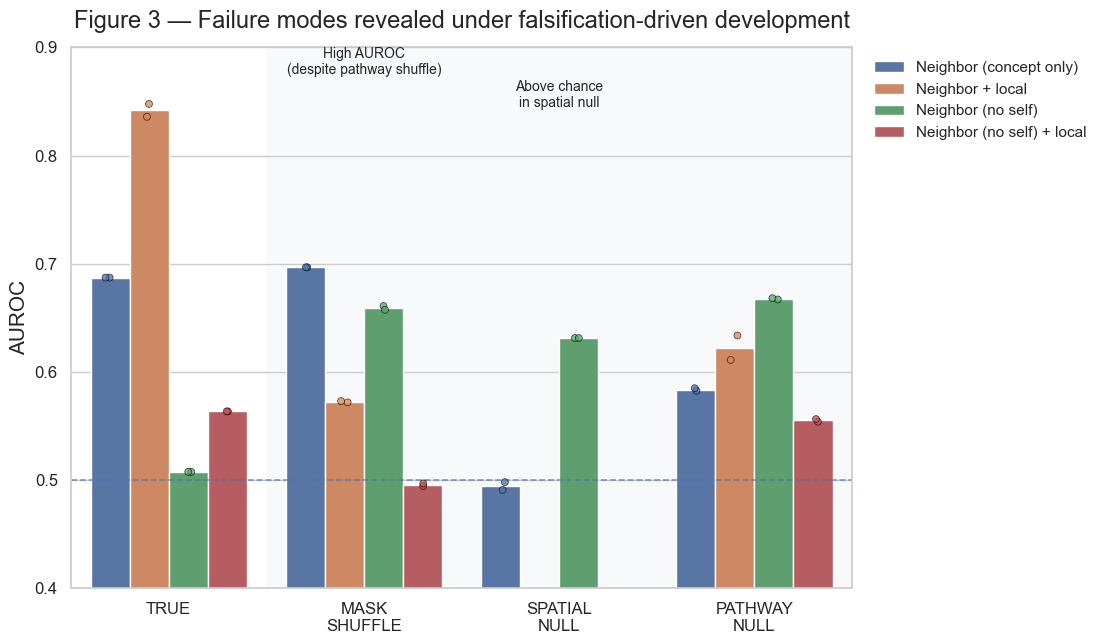

In [13]:
# Figure 3A — Failure modes revealed under falsification-driven development

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ablation = pd.read_csv(prototype_dir / "ablation_results.csv")

ablation["config"] = (
    ablation["concept_mode"].astype(str) + " + " +
    ablation["classifier_input"].astype(str)
)

label_map = {
    "neighbor_only + concept": "Neighbor (concept only)",
    "neighbor_only + local_plus_concept": "Neighbor + local",
    "neighbor_minus_self + concept": "Neighbor (no self)",
    "neighbor_minus_self + local_plus_concept": "Neighbor (no self) + local",
}

world_order = ["TRUE", "MASK_SHUFFLE", "SPATIAL_NULL", "PATHWAY_NULL"]
world_labels = ["TRUE", "MASK\nSHUFFLE", "SPATIAL\nNULL", "PATHWAY\nNULL"]
config_order = list(label_map.values())

plot_df = ablation.copy()
plot_df["config"] = plot_df["config"].map(label_map)
plot_df = plot_df.dropna(subset=["config"]).copy()
plot_df["world"] = pd.Categorical(plot_df["world"], categories=world_order, ordered=True)
plot_df["config"] = pd.Categorical(plot_df["config"], categories=config_order, ordered=True)
plot_df = plot_df.sort_values(["world", "config"])

mean_df = (
    plot_df.groupby(["world", "config"], as_index=False)["auroc"]
    .mean()
)

plt.figure(figsize=(11.2, 6.6))
ax = plt.gca()

# Light shading for falsification worlds
for i, world in enumerate(world_order):
    if world != "TRUE":
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.04, zorder=0)

# Mean bars
sns.barplot(
    data=mean_df,
    x="world",
    y="auroc",
    hue="config",
    order=world_order,
    hue_order=config_order,
    errorbar=None,
    ax=ax
)

# Seed-level points
sns.stripplot(
    data=plot_df,
    x="world",
    y="auroc",
    hue="config",
    order=world_order,
    hue_order=config_order,
    dodge=True,
    alpha=0.75,
    size=5,
    linewidth=0.5,
    edgecolor="black",
    ax=ax
)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
n = len(config_order)
ax.legend(
    handles[:n],
    labels[:n],
    title=None,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=11
)

# Chance line
ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.7)

# Adjusted annotations (lower to avoid title overlap)
ax.text(1, 0.875, "High AUROC\n(despite pathway shuffle)", ha="center", fontsize=10)
ax.text(2, 0.845, "Above chance\nin spatial null", ha="center", fontsize=10)

# Labels
ax.set_title("Figure 3 — Failure modes revealed under falsification-driven development", fontsize=17, pad=14)
ax.set_xlabel("")
ax.set_ylabel("AUROC", fontsize=15)
ax.set_ylim(0.40, 0.90)
ax.set_xticklabels(world_labels, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()

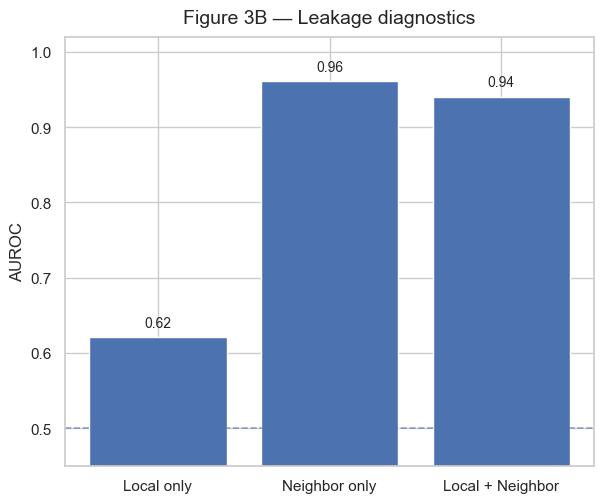

In [21]:
# Figure 3B — Final version (clean, no extra annotations)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

proto_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype")
df = pd.read_csv(proto_dir / "phase1b_leakage_results.csv")

label_map = {
    "neighbor_only": "Neighbor only",
    "local_only": "Local only",
    "local_plus_neighbor": "Local + Neighbor",
}
df["view"] = df["view"].map(label_map)

order = ["Local only", "Neighbor only", "Local + Neighbor"]
df["view"] = pd.Categorical(df["view"], categories=order, ordered=True)
df = df.sort_values("view")

fig, ax = plt.subplots(figsize=(6.2, 5.2))

bars = ax.bar(df["view"], df["auroc"])

# Chance line
ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

# Value labels only
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.01,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Figure 3B — Leakage diagnostics", fontsize=14, pad=10)
ax.set_ylabel("AUROC")
ax.set_xlabel("")
ax.set_ylim(0.45, 1.02)

plt.tight_layout()
plt.show()

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_89496/1500180572.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(world_labels)


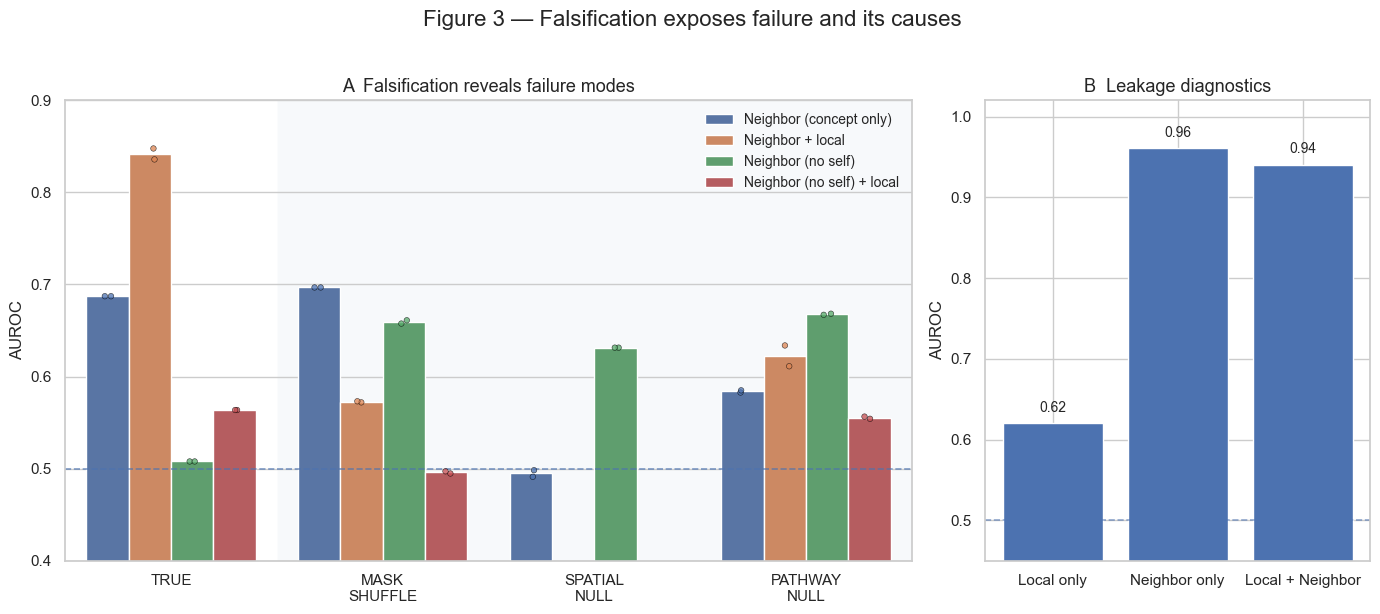

Saved:
/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures/figure_3.png
/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures/figure_3.pdf


In [24]:
# Figure 3 — Combined panels (A + B)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

proto_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Load data
# ---------------------------
ablation = pd.read_csv(proto_dir / "ablation_results.csv")
leak_df = pd.read_csv(proto_dir / "phase1b_leakage_results.csv")

# ---------------------------
# Prepare Figure 3A data
# ---------------------------
ablation["config"] = (
    ablation["concept_mode"].astype(str) + " + " +
    ablation["classifier_input"].astype(str)
)

label_map_A = {
    "neighbor_only + concept": "Neighbor (concept only)",
    "neighbor_only + local_plus_concept": "Neighbor + local",
    "neighbor_minus_self + concept": "Neighbor (no self)",
    "neighbor_minus_self + local_plus_concept": "Neighbor (no self) + local",
}

world_order = ["TRUE", "MASK_SHUFFLE", "SPATIAL_NULL", "PATHWAY_NULL"]
world_labels = ["TRUE", "MASK\nSHUFFLE", "SPATIAL\nNULL", "PATHWAY\nNULL"]
config_order = list(label_map_A.values())

plot_df = ablation.copy()
plot_df["config"] = plot_df["config"].map(label_map_A)
plot_df = plot_df.dropna(subset=["config"]).copy()
plot_df["world"] = pd.Categorical(plot_df["world"], categories=world_order, ordered=True)
plot_df["config"] = pd.Categorical(plot_df["config"], categories=config_order, ordered=True)

mean_df = (
    plot_df.groupby(["world", "config"], as_index=False)["auroc"]
    .mean()
)

# ---------------------------
# Prepare Figure 3B data
# ---------------------------
label_map_B = {
    "neighbor_only": "Neighbor only",
    "local_only": "Local only",
    "local_plus_neighbor": "Local + Neighbor",
}

leak_df["view"] = leak_df["view"].map(label_map_B)
order_B = ["Local only", "Neighbor only", "Local + Neighbor"]
leak_df["view"] = pd.Categorical(leak_df["view"], categories=order_B, ordered=True)
leak_df = leak_df.sort_values("view")

# ---------------------------
# Plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [2.2, 1]})

# Panel A
ax = axes[0]
for i, world in enumerate(world_order):
    if world != "TRUE":
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.04, zorder=0)

sns.barplot(
    data=mean_df,
    x="world",
    y="auroc",
    hue="config",
    order=world_order,
    hue_order=config_order,
    errorbar=None,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="world",
    y="auroc",
    hue="config",
    order=world_order,
    hue_order=config_order,
    dodge=True,
    alpha=0.75,
    size=4,
    linewidth=0.4,
    edgecolor="black",
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
n = len(config_order)
ax.legend(handles[:n], labels[:n], frameon=False, fontsize=10)

ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_title("A  Falsification reveals failure modes", fontsize=13)
ax.set_ylabel("AUROC")
ax.set_xlabel("")
ax.set_ylim(0.40, 0.90)
ax.set_xticklabels(world_labels)

# Panel B
ax2 = axes[1]
bars = ax2.bar(leak_df["view"], leak_df["auroc"])

ax2.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
             ha="center", va="bottom", fontsize=10)

ax2.set_title("B  Leakage diagnostics", fontsize=13)
ax2.set_ylabel("AUROC")
ax2.set_xlabel("")
ax2.set_ylim(0.45, 1.02)

# Title
fig.suptitle("Figure 3 — Falsification exposes failure and its causes", fontsize=16, y=1.02)

plt.tight_layout()

# ---------------------------
# Save
# ---------------------------
png_path = out_dir / "figure_3.png"
pdf_path = out_dir / "figure_3.pdf"

#fig.savefig(png_path, dpi=300, bbox_inches="tight")
#fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved:\n{png_path}\n{pdf_path}")

## Figure 4 — Final prototype behavior under falsification

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_89496/3832301760.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(world_labels)


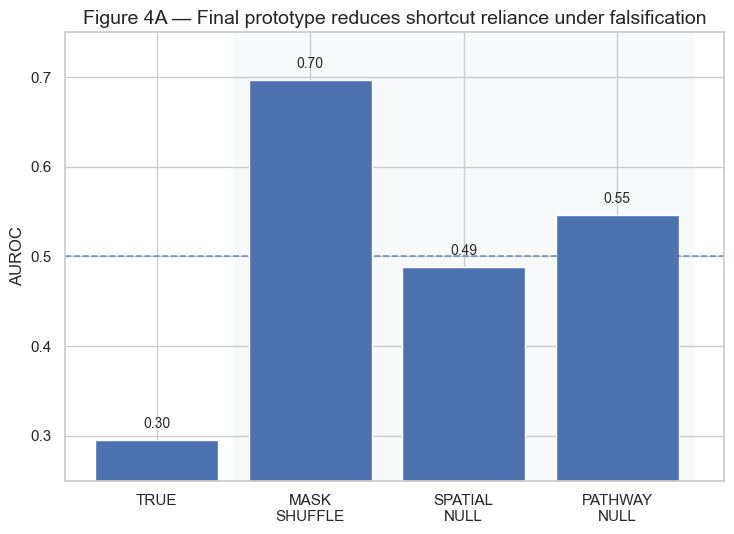

Saved:
/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures/figure_4A.png
/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures/figure_4A.pdf


In [26]:
# Figure 4A — Final prototype behavior under falsification (corrected model)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

proto_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(proto_dir / "phase1c_corrected_results.csv")

world_order = ["TRUE", "MASK_SHUFFLE", "SPATIAL_NULL", "PATHWAY_NULL"]
world_labels = ["TRUE", "MASK\nSHUFFLE", "SPATIAL\nNULL", "PATHWAY\nNULL"]

df["world"] = pd.Categorical(df["world"], categories=world_order, ordered=True)
df = df.sort_values("world")

# Plot
fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars = ax.bar(df["world"], df["auroc"])

# Shade falsification worlds
for i, world in enumerate(world_order):
    if world != "TRUE":
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.04, zorder=0)

# Chance line
ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.7)

# Values
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10)

# Labels
ax.set_title("Figure 4A — Final prototype reduces shortcut reliance under falsification", fontsize=14)
ax.set_ylabel("AUROC")
ax.set_xlabel("")
ax.set_ylim(0.25, 0.75)
ax.set_xticklabels(world_labels)

plt.tight_layout()

# Save
png_path = out_dir / "figure_4A.png"
pdf_path = out_dir / "figure_4A.pdf"

#fig.savefig(png_path, dpi=300, bbox_inches="tight")
#fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved:\n{png_path}\n{pdf_path}")

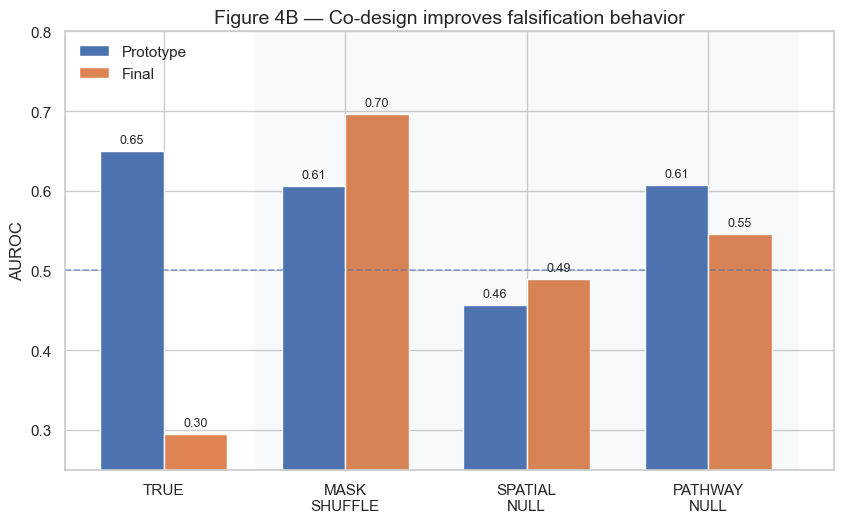

In [29]:
# Figure 4B — Final clean version (no annotations)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

proto_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")

ablation = pd.read_csv(proto_dir / "ablation_results.csv")
final_df = pd.read_csv(proto_dir / "phase1c_corrected_results.csv")

ablation["config"] = (
    ablation["concept_mode"].astype(str) + " + " +
    ablation["classifier_input"].astype(str)
)

world_order = ["TRUE", "MASK_SHUFFLE", "SPATIAL_NULL", "PATHWAY_NULL"]
world_labels = ["TRUE", "MASK\nSHUFFLE", "SPATIAL\nNULL", "PATHWAY\nNULL"]

proto_summary = (
    ablation.groupby("world", as_index=False)["auroc"]
    .mean()
    .rename(columns={"auroc": "Prototype"})
)

final_summary = (
    final_df[["world", "auroc"]]
    .rename(columns={"auroc": "Final"})
)

df = proto_summary.merge(final_summary, on="world")
df["world"] = pd.Categorical(df["world"], categories=world_order, ordered=True)
df = df.sort_values("world")

fig, ax = plt.subplots(figsize=(8.6, 5.4))

x = range(len(world_order))
w = 0.35

b1 = ax.bar([i - w/2 for i in x], df["Prototype"], width=w, label="Prototype")
b2 = ax.bar([i + w/2 for i in x], df["Final"], width=w, label="Final")

# subtle shading
for i, world in enumerate(world_order):
    if world != "TRUE":
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.04)

# chance
ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

# values
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", fontsize=9)

ax.set_title("Figure 4B — Co-design improves falsification behavior", fontsize=14)
ax.set_ylabel("AUROC")
ax.set_ylim(0.25, 0.80)
ax.set_xticks(list(x))
ax.set_xticklabels(world_labels)
ax.legend(frameon=False)

plt.tight_layout()

#fig.savefig(out_dir / "figure_4B.png", dpi=300, bbox_inches="tight")
#fig.savefig(out_dir / "figure_4B.pdf", bbox_inches="tight")

plt.show()

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_89496/57148267.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(world_labels)


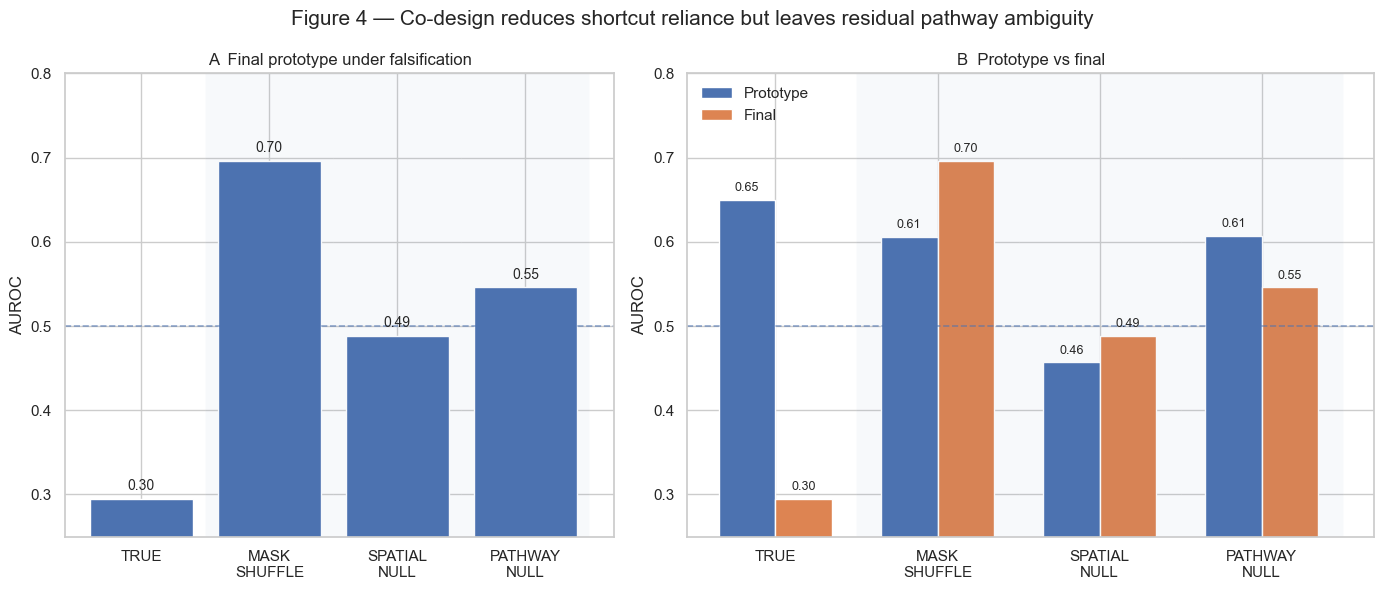

In [32]:
# Figure 4 — Combined panels

# (same code as before up to plotting...)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 1.5]})

# ===== Panel A =====
ax = axes[0]

bars = ax.bar(dfA["world"], dfA["auroc"])

for i, world in enumerate(world_order):
    if world != "TRUE":
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.04)

ax.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", fontsize=10)

ax.set_title("A  Final prototype under falsification", fontsize=12)
ax.set_ylabel("AUROC")
ax.set_ylim(0.25, 0.80)  # ← MATCH Panel B
ax.set_xticklabels(world_labels)

# ===== Panel B =====
ax2 = axes[1]

x = range(len(world_order))
w = 0.35

b1 = ax2.bar([i - w/2 for i in x], dfB["Prototype"], width=w, label="Prototype")
b2 = ax2.bar([i + w/2 for i in x], dfB["Final"], width=w, label="Final")

for i, world in enumerate(world_order):
    if world != "TRUE":
        ax2.axvspan(i - 0.5, i + 0.5, alpha=0.04)

ax2.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.2f}", ha="center", fontsize=9)

ax2.set_title("B  Prototype vs final", fontsize=12)
ax2.set_ylabel("AUROC")
ax2.set_ylim(0.25, 0.80)
ax2.set_xticks(list(x))
ax2.set_xticklabels(world_labels)
ax2.legend(frameon=False)

# Global title (slightly smaller)
fig.suptitle(
    "Figure 4 — Co-design reduces shortcut reliance but leaves residual pathway ambiguity",
    fontsize=15
)

plt.tight_layout()

# Save (same as before)
fig.savefig(out_dir / "figure_4.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure_4.pdf", bbox_inches="tight")

plt.show()

## Figure 5 — Axis-level identifiability across datasets

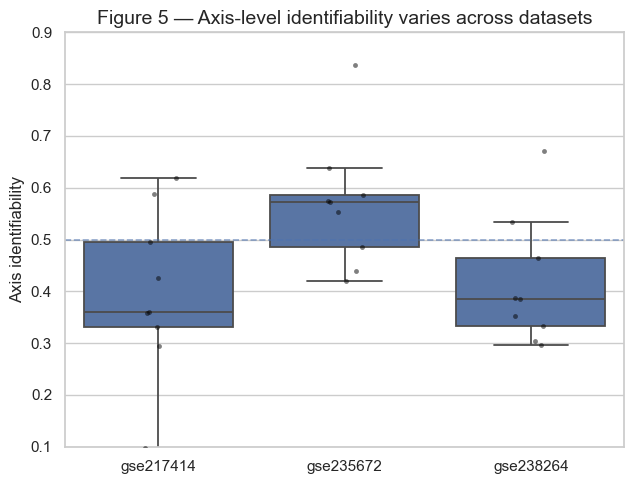

In [36]:
# Figure 5 — Axis-level identifiability

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")

files = [
    "axis_ident_summary_gse217414.csv",
    "axis_ident_summary_gse235672.csv",
    "axis_ident_summary_gse238264.csv",
]

dfs = []
for f in files:
    df = pd.read_csv(validation_dir / f)
    df["dataset"] = f.replace("axis_ident_summary_", "").replace(".csv", "")
    dfs.append(df)

plot_df = pd.concat(dfs, ignore_index=True)

dataset_order = ["gse217414", "gse235672", "gse238264"]
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=dataset_order, ordered=True)

plt.figure(figsize=(6.5, 5))

sns.boxplot(
    data=plot_df,
    x="dataset",
    y="mean",
    showfliers=False,
    linewidth=1.3
)

sns.stripplot(
    data=plot_df,
    x="dataset",
    y="mean",
    color="black",
    alpha=0.5,
    size=3.5
)

plt.axhline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

plt.title("Figure 5 — Axis-level identifiability varies across datasets", fontsize=14)
plt.ylabel("Axis identifiability")
plt.xlabel("")
plt.ylim(0.1, 0.9)  # tighter range

plt.tight_layout()

plt.savefig(out_dir / "figure_5.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "figure_5.pdf", bbox_inches="tight")

plt.show()

## Figure 6 — Spatial smoothness vs axis separation

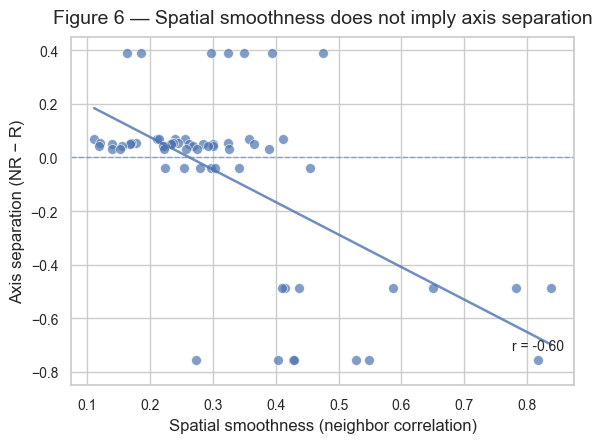

In [39]:
# Figure 6 — Spatial smoothness vs axis separation 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# Load data
ident = pd.read_csv(validation_dir / "axis_contrib_gse238264.csv")
smooth = pd.read_csv(validation_dir / "spatial_smoothness_gse238264.csv")

plot_df = ident.merge(smooth, on="axis")

x_col = "neighbor_corr"
y_col = "delta_mean_NR_minus_R"

# Correlation
r, p = pearsonr(plot_df[x_col], plot_df[y_col])

fig, ax = plt.subplots(figsize=(6.0, 4.6))

# Scatter
sns.scatterplot(
    data=plot_df,
    x=x_col,
    y=y_col,
    s=50,
    alpha=0.7,
    ax=ax
)

# Regression
sns.regplot(
    data=plot_df,
    x=x_col,
    y=y_col,
    scatter=False,
    ci=None,
    robust=False,
    line_kws={"linewidth": 1.8, "alpha": 0.8},
    ax=ax
)

# Reference line
ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.5)

# Labels
ax.set_title("Figure 6 — Spatial smoothness does not imply axis separation", fontsize=14, pad=10)
ax.set_xlabel("Spatial smoothness (neighbor correlation)", fontsize=12)
ax.set_ylabel("Axis separation (NR − R)", fontsize=12)
ax.set_ylim(-0.85, 0.45)

# Correlation annotation
ax.text(
    0.98, 0.10,
    f"r = {r:.2f}",
    transform=ax.transAxes,
    ha="right",
    fontsize=10
)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# Save
fig.savefig(out_dir / "figure_6.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure_6.pdf", bbox_inches="tight")

plt.show()

## Figure 7 — Spatial organization of representative programs

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_89496/2167916966.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.95])


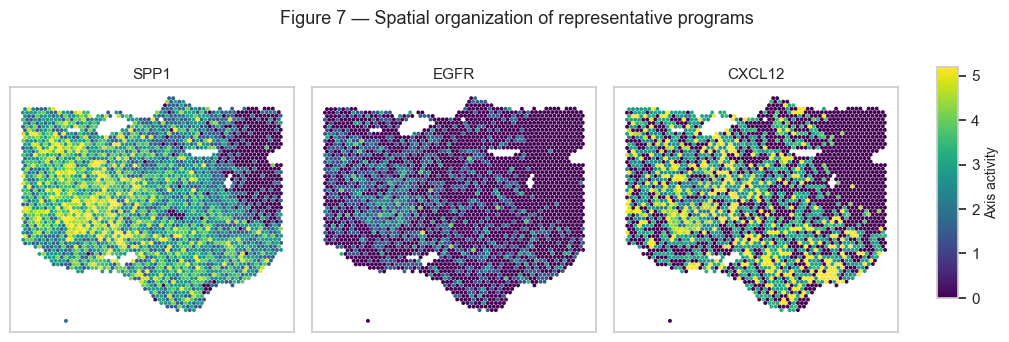

In [42]:
# Figure 7 — Spatial organization

import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")
out_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")

with open(validation_dir / "axis_tables_gse238264.pkl", "rb") as f:
    axis_tables_gse238264 = pickle.load(f)

sample_id = sorted(axis_tables_gse238264.keys())[0]

coords = np.asarray(axis_tables_gse238264[sample_id]["spatial"])
X_axis = np.asarray(axis_tables_gse238264[sample_id]["X_axis"])
axis_names = list(axis_tables_gse238264[sample_id]["axis_names"])

selected_axes = ["SPP1", "EGFR", "CXCL12"]
indices = [axis_names.index(a) for a in selected_axes]

# -----------------------------
# Balanced robust scaling (KEY FIX)
# -----------------------------
vals = X_axis[:, indices].reshape(-1)
vmin = np.percentile(vals, 5)
vmax = np.percentile(vals, 95)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))

for ax, idx, name in zip(axes, indices, selected_axes):
    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=X_axis[:, idx],
        cmap="viridis",
        s=8,  # slightly larger again → better readability
        vmin=vmin,
        vmax=vmax,
        linewidths=0
    )
    ax.set_title(name, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

# Layout
plt.subplots_adjust(right=0.88, wspace=0.15)

cbar_ax = fig.add_axes([0.90, 0.18, 0.02, 0.64])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Axis activity", fontsize=10)

fig.suptitle(
    "Figure 7 — Spatial organization of representative programs",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 0.88, 0.95])

# Save
fig.savefig(out_dir / "figure_7.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure_7.pdf", bbox_inches="tight")

plt.show()

## Figure 8 — Axis separation differs by response

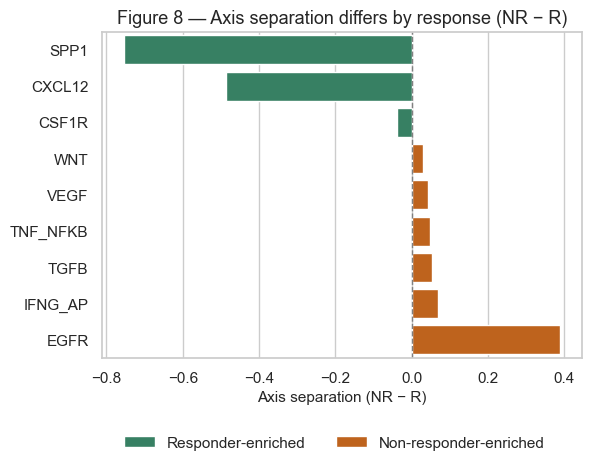

In [68]:
# FIGURE 8 — Axis separation differs by response (NR − R)


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")

# Load + sort
df = pd.read_csv(validation_dir / "axis_contrib_gse238264.csv")
df = df.sort_values("delta_mean_NR_minus_R", ascending=True)

# Groups
df["group"] = df["delta_mean_NR_minus_R"].apply(
    lambda x: "Responder-enriched" if x < 0 else "Non-responder-enriched"
)

palette = {
    "Responder-enriched": "#2b8c66",
    "Non-responder-enriched": "#d95f02"
}

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.8))

sns.barplot(
    data=df,
    x="delta_mean_NR_minus_R",
    y="axis",
    hue="group",
    dodge=False,
    palette=palette,
    ax=ax
)

# Remove default legend
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# Zero line
ax.axvline(0, linestyle="--", linewidth=1, color="gray")

# Labels
ax.set_title("Figure 8 — Axis separation differs by response (NR − R)", fontsize=13)
ax.set_xlabel("Axis separation (NR − R)", fontsize=11)
ax.set_ylabel("")

# -----------------------------
# LEGEND — BELOW PLOT (NO OVERLAP)
# -----------------------------
legend = fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# Give space for legend
plt.subplots_adjust(bottom=0.20)

# -----------------------------
# SAVE (include legend safely)
# -----------------------------
output_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "figure_8.png",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=[legend]
)

plt.savefig(
    output_dir / "figure_8.pdf",
    bbox_inches="tight",
    bbox_extra_artists=[legend]
)

plt.show()

## Figure 9 — Significance of axis-level separation

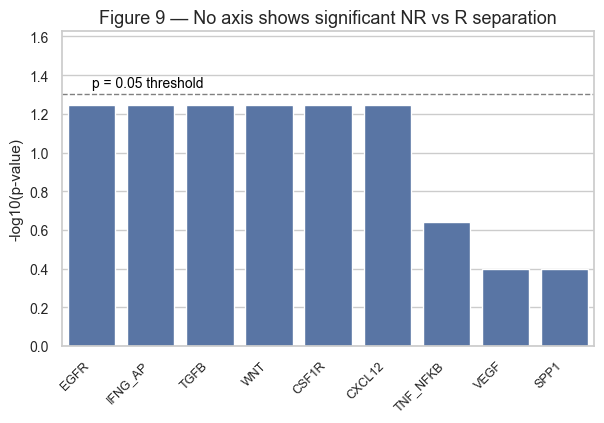

In [69]:
# FIGURE 9 — Significance of axis-level separation (NR vs R)


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

validation_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation")

# Load + process
df = pd.read_csv(validation_dir / "axis_contrib_gse238264.csv")
df = df.sort_values("p_mean")

df["neglog10_p"] = -np.log10(df["p_mean"])
threshold = -np.log10(0.05)

# -----------------------------
# FIGURE
# -----------------------------
plt.figure(figsize=(6.2, 4.4))

sns.barplot(
    data=df,
    x="axis",
    y="neglog10_p",
    color="#4c72b0",
    errorbar=None
)

# Threshold line
plt.axhline(threshold, linestyle="--", linewidth=1, color="gray")

# FIXED label (tight + aligned to line)
plt.text(
    x=0,
    y=threshold + 0.02,   # ← small offset only
    s="p = 0.05 threshold",
    ha="left",
    va="bottom",
    fontsize=10,
    color="black"
)

# Labels
plt.title("Figure 9 — No axis shows significant NR vs R separation", fontsize=13)
plt.xlabel("")
plt.ylabel("-log10(p-value)", fontsize=11)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)

plt.ylim(0, threshold * 1.25)

plt.tight_layout()

# -----------------------------
# SAVE
# -----------------------------
output_dir = Path("/Users/sally/Desktop/Prototype_validation/figure_artifacts/final_figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "figure_9.png", dpi=300)
plt.savefig(output_dir / "figure_9.pdf")

plt.show()